# Multi-hop factorization: Kronecker spectrum versus dense $K_{\mathrm{eff}}$

This notebook checks the monomial $P=2$ networked map

$$
K_{\mathrm{eff}} = \sum_{k=0}^{P} \widehat{A}^{k} \otimes K_{k}
$$

on a path with $N=4$ nodes and latent width $d=2$. When the discrete
graph operator is eligible, `.spectrum` uses the pencil
$B(\lambda)=\sum_k \lambda^k K_k$ (Kronecker reduction), not a sum of
independent factor eigenvalues. Dense assembly of $K_{\mathrm{eff}}$ is
the reference. A second cell only checks that `fit` warns when a
two-layer encoder exceeds the operator hop degree.

**Honesty.** This is an algebraic agreement check plus a hop-mismatch
warning exercise. It is **not** a forecasting contest, **not** a claim that
raising $P$ closes the example-38 hold-out MSE gap (approximately $0.71$
versus $0.019$), and **not** a continuous-graph result (that generator stays
one-tap). Factory `koopman_filter_degree` remains $1$; every fit here passes
$P$ explicitly. This notebook does **not** download METR-LA.


## Setup

Imports, a four-node path, and the float64 hop factors used in the operator
unit tests (`rtol=1e-6`, `atol=1e-8` on eigenvalues). Written against
`koopman_graph` 0.15.x.


In [1]:
import os
import warnings

from tqdm.std import TqdmExperimentalWarning, TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import torch

import koopman_graph
from koopman_graph import (
    GNNDecoder,
    GNNEncoder,
    GraphKoopmanModel,
    GraphKoopmanOperator,
    compute_spectrum,
)
from koopman_graph.datasets.synthetic import SyntheticDynamicGraphBenchmark
from koopman_graph.graph_utils.topology import dense_symmetric_normalized_adjacency
from koopman_graph.nn import ReceptiveFieldMismatchWarning
from koopman_graph.operators.kronecker_spectrum import (
    spectrum_k_eff_kronecker_polynomial,
)
from koopman_graph.operators.polynomial_graph import dense_polynomial_kronecker

SEED = 0
N = 4
D = 2
P = 2
DT = 0.25
# Match tests/operators/test_kronecker_spectrum.py (float64 polynomial).
RTOL = 1e-6
ATOL = 1e-8
torch.manual_seed(SEED)

src = [0, 1, 1, 2, 2, 3]
dst = [1, 0, 2, 1, 3, 2]
edge_index = torch.tensor([src, dst], dtype=torch.long)
dtype = torch.float64
k0 = torch.tensor([[0.50, 0.10], [0.00, 0.40]], dtype=dtype)
k1 = torch.tensor([[0.08, 0.02], [0.01, 0.05]], dtype=dtype)
k2 = torch.tensor([[0.03, 0.00], [0.00, 0.02]], dtype=dtype)
hops = (k0, k1, k2)

print(
    f"koopman_graph {koopman_graph.__version__}; torch {torch.__version__}; "
    f"N={N}, d={D}, P={P}"
)


koopman_graph 0.15.0; torch 2.13.0; N=4, d=2, P=2


## Motivation and background

Assembling the ambient $(N\cdot d)\times(N\cdot d)$ matrix and calling
`torch.linalg.eig` is the direct spectrum. When the discrete graph
operator is eligible, `.spectrum` instead diagonalizes $N$ pencils of
size $d\times d$:

$$
B(\lambda)=\sum_{k=0}^{P}\lambda^{k}K_{k},\qquad
\mu_{ij}\in\operatorname{eig}\bigl(B(\lambda_i)\bigr).
$$

Those $\mu$ **are** the eigenvalues of $K_{\mathrm{eff}}$. They are
**not** the growth rates $\log|\mu|/\Delta t$ stored on
`KoopmanSpectrum.growth_rates` (here $\Delta t=0.25$ only fills that
metadata). Pairing independent factor eigenvalues
$\nu_j^{(0)}+\lambda_i\nu_j^{(1)}+\lambda_i^{2}\nu_j^{(2)}$ is the
formula the reduction must not use unless the $K_k$ share an eigenbasis.

Eligibility (all required): a single shared self factor;
`adjacency` in `{"symmetric", "random_walk"}`; `sparsity` in
`{"dense", "block_diagonal"}`. Dual random-walk, `sparsity="distributed"`
(Arnoldi Ritz values), and orbit / isotypic self banks are ineligible.
The helper returns `None` when the reduction is numerically unreliable;
callers then fall back to dense assembly. Continuous graph stays the
one-tap generator.

This monomial hop map is **not** the modularized EDMD of Guo, Schaller,
Worthmann, and Streif (2025). That paper is related networked-EDMD
literature only.

Encoder message-passing hops and operator $P$ are different maps.
Default factory `koopman_filter_degree` is $1$. A two-layer GCN mixes
two hops; that encoder radius exceeds a $P=1$ operator, and `fit` emits
`ReceptiveFieldMismatchWarning` without stopping training.


## Minimal example

Three routes should agree on eigenvalues (unordered multiset, greedy nearest
match) on this eligible symmetric path:

1. `spectrum_k_eff_kronecker_polynomial` (power-user helper).
2. `GraphKoopmanOperator.spectrum` (auto-routed Kronecker path).
3. `compute_spectrum` on `effective_matrix` / `dense_polynomial_kronecker`.

Tolerance: relative $10^{-6}$ with absolute floor $10^{-8}$, copied from the
float64 $N=4$, $d=2$ operator tests — not an invented metric.


In [2]:
def eigvals_match(left, right, rtol=RTOL, atol=ATOL):
    if left.shape != right.shape:
        return False
    remaining = right.detach().clone()
    for value in left.detach():
        index = int(torch.argmin((remaining - value).abs()))
        if not torch.isclose(value, remaining[index], rtol=rtol, atol=atol):
            return False
        remaining[index] = complex(float("inf"), float("inf"))
    return True


adj = dense_symmetric_normalized_adjacency(edge_index, N, dtype=dtype)
K_dense = dense_polynomial_kronecker(adj, hops)
spec_dense = compute_spectrum(K_dense, DT)
spec_helper = spectrum_k_eff_kronecker_polynomial(
    hop_matrices=hops,
    edge_index=edge_index,
    num_nodes=N,
    adjacency="symmetric",
    time_step=DT,
)
assert spec_helper is not None

op = GraphKoopmanOperator(D, filter_degree=P).double()
op.set_dense_matrices(k0, k1, hop_matrices=(k2,))
K_eff = op.effective_matrix(edge_index, N)
spec_op = op.spectrum(edge_index, num_nodes=N, time_step=DT)
spec_from_keff = compute_spectrum(K_eff, DT)

print("helper vs dense_polynomial_kronecker:",
      eigvals_match(spec_helper.eigenvalues, spec_dense.eigenvalues))
print("operator.spectrum vs effective_matrix:",
      eigvals_match(spec_op.eigenvalues, spec_from_keff.eigenvalues))
print("helper vs operator.spectrum:",
      eigvals_match(spec_helper.eigenvalues, spec_op.eigenvalues))
print("K_eff shape:", tuple(K_eff.shape), "  ||K_eff - dense||_F =",
      float(torch.linalg.norm(K_eff - K_dense).item()))


helper vs dense_polynomial_kronecker: True
operator.spectrum vs effective_matrix: True
helper vs operator.spectrum: True
K_eff shape: (8, 8)   ||K_eff - dense||_F = 0.0


## Progressive deep dive

### Independent factor eigenvalues

Pairing $\nu_j^{(0)} + \lambda_i \nu_j^{(1)} + \lambda_i^2 \nu_j^{(2)}$ from
**separate** eigendecompositions of $K_k$ is the anti-oracle. On this $K_0$
(upper triangular) and $K_1$ (lower triangular) pair the factors do not
share an eigenbasis, so the pairing fails the same tolerance while the
pencil still matches dense `eig`.


In [3]:
k0_naive = torch.tensor([[0.50, 0.40], [0.00, 0.20]], dtype=dtype)
k1_naive = torch.tensor([[0.10, 0.00], [0.35, 0.30]], dtype=dtype)
k2_zero = torch.zeros(2, 2, dtype=dtype)
hops_naive = (k0_naive, k1_naive, k2_zero)
dense_naive = torch.linalg.eigvals(dense_polynomial_kronecker(adj, hops_naive))
reduced_naive = spectrum_k_eff_kronecker_polynomial(
    hop_matrices=hops_naive,
    edge_index=edge_index,
    num_nodes=N,
    adjacency="symmetric",
    time_step=DT,
)
assert reduced_naive is not None
print(
    "pencil vs dense (should match):",
    eigvals_match(reduced_naive.eigenvalues, dense_naive),
)

adj_eigs = torch.linalg.eigvalsh(adj)
nu0 = torch.linalg.eigvals(k0_naive)
nu1 = torch.linalg.eigvals(k1_naive)
nu2 = torch.linalg.eigvals(k2_zero)
nu0 = nu0[torch.argsort(nu0.real)]
nu1 = nu1[torch.argsort(nu1.real)]
nu2 = nu2[torch.argsort(nu2.real)]
independent = torch.cat(
    [nu0 + lam * nu1 + (lam ** 2) * nu2 for lam in adj_eigs]
)
print(
    "independent factor eigs vs dense (should fail):",
    eigvals_match(independent, dense_naive),
)


pencil vs dense (should match): True
independent factor eigs vs dense (should fail): False


### Encoder hops versus operator $P$

A two-layer GCN mixes two hops. With explicit `koopman_filter_degree=1`,
that **encoder** radius exceeds the operator hop degree, so `fit` emits
`ReceptiveFieldMismatchWarning`. The same codec with
`koopman_filter_degree=2` is hop-matched and should stay quiet. Five
epochs on a tiny path-diffusion draw only exercise the warning flag.
Hold-out mean squared error (MSE) is not computed here and is not a
forecasting comparison.


In [4]:
train = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=N,
    num_timesteps=16,
    seed=0,
    in_channels=D,
    topology="path",
    diffusion_rate=0.35,
    decay_rate=0.92,
    noise_std=0.0,
    initial_state="ones",
)


def fit_degree(degree, epochs=5):
    torch.manual_seed(SEED)
    model = GraphKoopmanModel(
        GNNEncoder(D, 16, D, num_layers=2),
        GNNDecoder(D, 16, D, num_layers=2),
        latent_dim=D,
        time_step=1.0,
        koopman="graph",
        koopman_filter_degree=degree,
    )
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ReceptiveFieldMismatchWarning)
        _ = model.fit(train, epochs=epochs, lr=5e-3, device="cpu")
    return any(
        issubclass(w.category, ReceptiveFieldMismatchWarning) for w in caught
    )


warn_p1 = fit_degree(1)
warn_p2 = fit_degree(2)
print(f"P=1 (2-layer encoder exceeds operator hops): warning={warn_p1}")
print(f"P=2 (hop-matched 2-layer encoder): warning={warn_p2}")


P=1 (2-layer encoder exceeds operator hops): warning=True
P=2 (hop-matched 2-layer encoder): warning=False


## Results

The scatter plots stored `KoopmanSpectrum.eigenvalues` for the helper
versus dense `eig` of $K_{\mathrm{eff}}$. Markers should overlap: those
values are $\mu=\operatorname{eig}(B(\lambda_i))$, not growth rates.
On this real-symmetric path they lie on the real axis. Agreement to the
documented float64 tolerance is the result; the figure is a visual
check, not a new metric.

The hop cell reports warning flags only (`True` at $P=1$, `False` at
$P=2$). It does not rank forecast MSE.


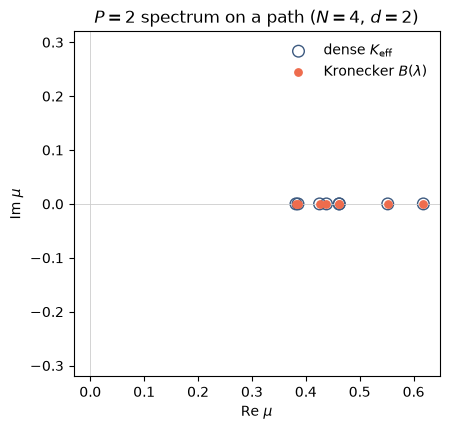

In [5]:
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.scatter(
    spec_dense.eigenvalues.real.detach(),
    spec_dense.eigenvalues.imag.detach(),
    s=70,
    facecolors="none",
    edgecolors="#3d5a80",
    label=r"dense $K_{\mathrm{eff}}$",
)
ax.scatter(
    spec_helper.eigenvalues.real.detach(),
    spec_helper.eigenvalues.imag.detach(),
    s=28,
    c="#ee6c4d",
    label=r"Kronecker $B(\lambda)$",
    zorder=3,
)
ax.axhline(0.0, color="0.8", linewidth=0.6)
ax.axvline(0.0, color="0.8", linewidth=0.6)
ax.set_xlabel(r"Re $\mu$")
ax.set_ylabel(r"Im $\mu$")
ax.set_title(rf"$P=2$ spectrum on a path ($N={N}$, $d={D}$)")
ax.set_aspect("equal", adjustable="datalim")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Interpretation / discussion

On this eligible path the three spectrum routes agree and
$\|K_{\mathrm{eff}}-K_{\mathrm{dense}}\|_F=0$. That is algebraic
identity, not forecast skill. The independent-factor pairing fails on
the same graph when $K_0$ and $K_1$ do not share an eigenbasis, which
is why the pencil $B(\lambda)$ is the reduction.

Reach for the Kronecker path when the eligibility gates hold and $d\ll N$
makes $N$ pencils cheaper than a dense $(N\cdot d)$ eigendecomposition
(order $O(N^3+N d^3)$ versus dense assembly). Do not use it for dual
adjacency, distributed Arnoldi, or orbit / isotypic self banks; those
routes stay on dense `effective_matrix` or leading-modulus Ritz values.
If the helper returns `None`, treat that as a fall-back signal, not a
spectrum. Continuous graph has no polynomial generator reduction here.

The hop warning only says the encoder radius exceeds operator $P$.
Raising $P$ does not close the example-38 one-tap versus joint
least-squares hold-out MSE gap (approximately $0.71$ versus $0.019$).
Factory $P$ stays $1$.


## Takeaways

- Use eligible discrete $P\ge 0$ spectrum when you want
  $\mu=\operatorname{eig}(B(\lambda_i))$ with
  $B(\lambda)=\sum_k\lambda^k K_k$, matching dense $K_{\mathrm{eff}}$
  at the documented float64 tolerance on this path.
- Do not pair independent factor eigenvalues unless the $K_k$ share an
  eigenbasis.
- Do not use the Kronecker path for dual / distributed / orbit layouts,
  or treat `None` as a spectrum. Continuous graph stays one-tap.
- Encoder hops and operator $P$ are different maps; `fit` warns when the
  encoder exceeds $P$. Factory $P$ stays $1$.
- Example 38's historical one-tap versus joint-LS gap is a separate
  protocol and is not attributed to hop order here.


## Further reading

- Sphinx: [matrix_free](../docs/source/matrix_free.rst),
  [limitations](../docs/source/limitations.rst),
  [faq](../docs/source/faq.rst),
  [architecture](../docs/source/architecture.rst),
  [api](../docs/source/api.rst)
  (`GraphKoopmanOperator.spectrum`,
  `GraphKoopmanOperator.effective_matrix`,
  `koopman_graph.operators.kronecker_spectrum.spectrum_k_eff_kronecker_polynomial`,
  `koopman_graph.operators.polynomial_graph.dense_polynomial_kronecker`,
  `ReceptiveFieldMismatchWarning`)
- Related notebook:
  [38_operator_factorization_ablation.ipynb](38_operator_factorization_ablation.ipynb)
  (one-tap versus joint LS; hop-matched $P\in\{0,1,2\}$ forecasting arm)
- Guo, Y., Schaller, M., Worthmann, K., and Streif, S. (2025).
  Modularized data-driven approximation of the Koopman operator and
  generator. *Physica D*, 476, 134651.
  [doi:10.1016/j.physd.2025.134651](https://doi.org/10.1016/j.physd.2025.134651)
  (`Guo2025ModularEDMD`; related networked-EDMD literature — **not** this
  monomial hop map)
